# I imported the train data

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [30]:
Train_data = pd.read_csv(r"C:\Users\Anthony Bannerman\Downloads\playground-series-s6e3\train.csv")

In [31]:
Train_data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [32]:
Train_data['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [33]:
Train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

# Step-by-Step Clean Pipeline

# I dropped the ID Column

In [34]:
Train_data = Train_data.drop('id', axis= 1)

In [35]:
Train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [36]:
Train_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


# I converted all the catergroical columns to numeric

In [37]:
# Convert target
Train_data['Churn'] = Train_data['Churn'].map({'Yes':1, 'No':0})

# One-hot encode everything else automatically
X = Train_data.drop(['Churn'], axis=1)
y = Train_data['Churn']

X_encoded = pd.get_dummies(X, drop_first=True)

In [38]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29,60.10,1653.85,True,True,True,True,False,False,...,False,False,False,False,True,False,True,False,False,True
1,0,58,69.50,3778.20,True,True,True,True,False,False,...,False,True,False,False,False,True,False,True,False,False
2,0,58,100.40,5841.35,True,True,False,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,0,1,69.70,70.70,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
4,0,1,70.45,70.45,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [39]:
y.head()

0    0
1    0
2    0
3    1
4    1
Name: Churn, dtype: int64

In [40]:
Train_data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Correlation Analysis

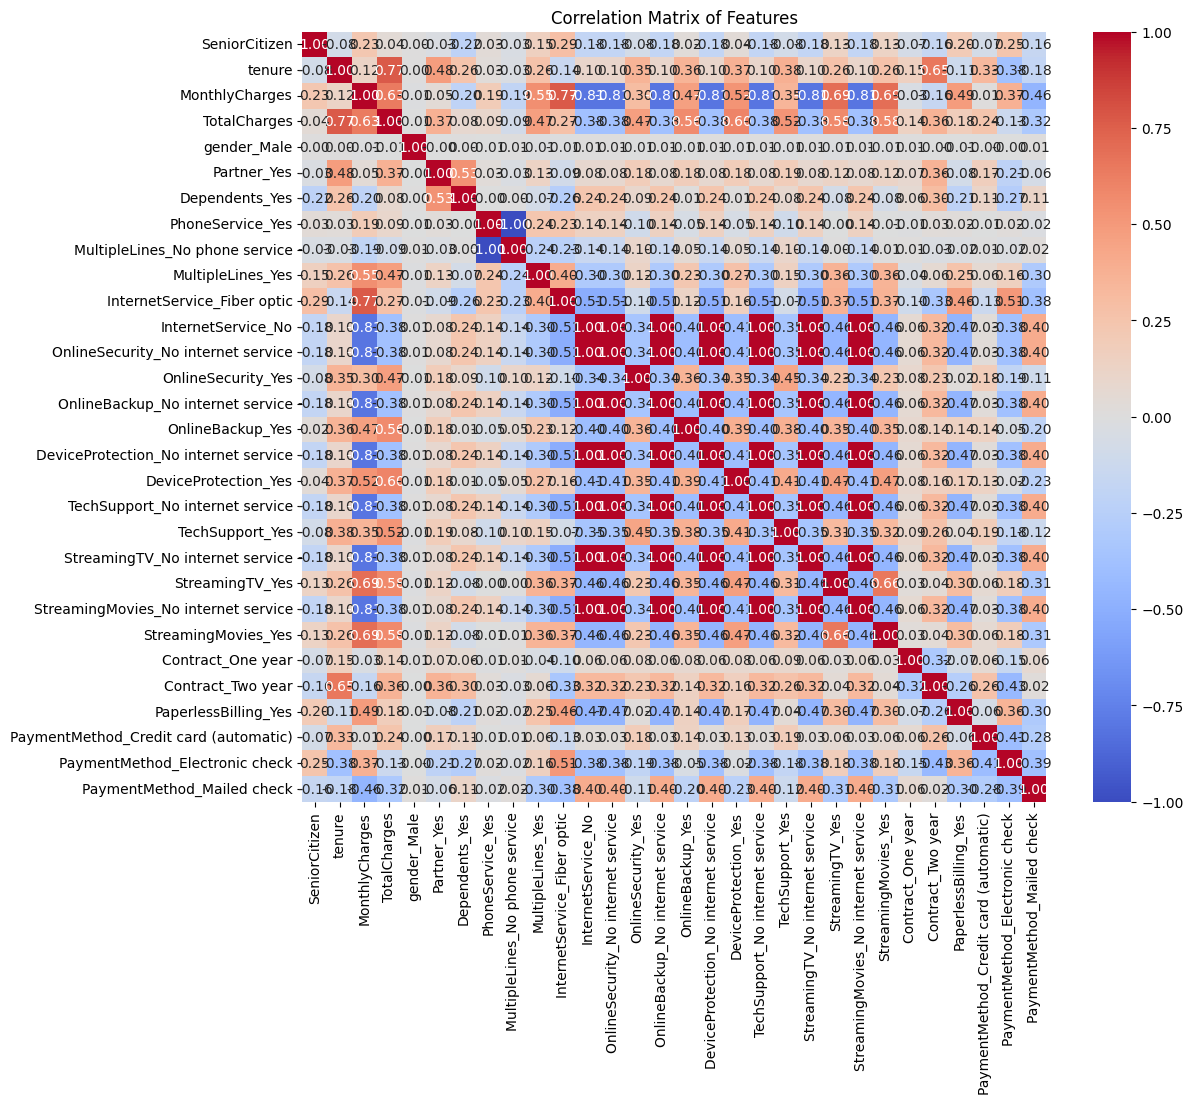

In [41]:
plt.figure(figsize=(12,10))
corr = X_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Features')
plt.show()

In [42]:
from scipy.stats import pearsonr

In [43]:
Train_data_corr = X_encoded.copy()
Train_data_corr["Churn"] = y

corr = Train_data_corr.corr()["Churn"].sort_values(ascending=False)
print(corr)

Churn                                    1.000000
PaymentMethod_Electronic check           0.476255
InternetService_Fiber optic              0.418819
PaperlessBilling_Yes                     0.285107
MonthlyCharges                           0.272997
SeniorCitizen                            0.236362
StreamingTV_Yes                          0.117280
MultipleLines_Yes                        0.114951
StreamingMovies_Yes                      0.114589
PhoneService_Yes                         0.034843
gender_Male                             -0.006808
MultipleLines_No phone service          -0.034843
DeviceProtection_Yes                    -0.074228
OnlineBackup_Yes                        -0.100109
PaymentMethod_Mailed check              -0.178668
Contract_One year                       -0.189436
TechSupport_Yes                         -0.191011
PaymentMethod_Credit card (automatic)   -0.201075
OnlineSecurity_Yes                      -0.204544
TotalCharges                            -0.218365


# Check class imbalance

In [44]:
y.value_counts(normalize=True)

Churn
0    0.774792
1    0.225208
Name: proportion, dtype: float64

# Separate Features and Target

In [45]:
X = X_encoded
y = Train_data['Churn']

# Train–Validation Split

In [46]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [48]:
pip install --upgrade xgboost

Note: you may need to restart the kernel to use updated packages.


# Training the model

In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [50]:
# Initialize the model
model = XGBClassifier(
    n_estimators=1200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50  # shows progress every 50 trees
)

# Predict probabilities on validation set
y_val_prob = model.predict_proba(X_val)[:, 1]

# Evaluate AUC
auc = roc_auc_score(y_val, y_val_prob)
print("Validation AUC:", auc)

[0]	validation_0-auc:0.90126


C:\Users\Anthony Bannerman\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:08:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-auc:0.91407
[100]	validation_0-auc:0.91553
[150]	validation_0-auc:0.91627
[200]	validation_0-auc:0.91663
[250]	validation_0-auc:0.91681
[300]	validation_0-auc:0.91694
[350]	validation_0-auc:0.91702
[400]	validation_0-auc:0.91705
[450]	validation_0-auc:0.91704
[500]	validation_0-auc:0.91705
[550]	validation_0-auc:0.91704
[600]	validation_0-auc:0.91703
[650]	validation_0-auc:0.91699
[700]	validation_0-auc:0.91695
[750]	validation_0-auc:0.91690
[800]	validation_0-auc:0.91686
[850]	validation_0-auc:0.91682
[900]	validation_0-auc:0.91679
[950]	validation_0-auc:0.91675
[1000]	validation_0-auc:0.91670
[1050]	validation_0-auc:0.91666
[1100]	validation_0-auc:0.91661
[1150]	validation_0-auc:0.91655
[1199]	validation_0-auc:0.91650
Validation AUC: 0.916499478875243


In [51]:
model = XGBClassifier(
    n_estimators=1200,        # number of boosting rounds
    learning_rate=0.03,       # small learning rate for stability
    max_depth=6,              # depth of each tree
    subsample=0.8,            # row sampling for each tree
    colsample_bytree=0.8,     # feature sampling for each tree
    scale_pos_weight=3.44,    # balances churn class
    random_state=42,
    eval_metric='auc',        # AUC evaluation
    use_label_encoder=False
)

# Fit the Model

In [52]:
model.fit(X_train, y_train)

C:\Users\Anthony Bannerman\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:10:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


# Predictions

In [53]:
y_pred_proba = model.predict_proba(X_val)[:,1]

# Evaluating the model

In [54]:
from sklearn.metrics import roc_auc_score

In [55]:
auc = roc_auc_score(y_val, y_pred_proba)
print("Validation AUC:", auc)

Validation AUC: 0.9169637905784221


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=1200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
            
y_val_prob_rf = rf_model.predict_proba(X_val)[:,1]
print("Validation AUC (RF):", roc_auc_score(y_val, y_val_prob_rf))

Validation AUC (RF): 0.9123979259173224


# I imported the test data and Sample Submission

In [68]:
Test_data = pd.read_csv(r"C:\Users\Anthony Bannerman\Downloads\playground-series-s6e3\test.csv")

In [69]:
Test_data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


# One-hot encode categorical columns

In [70]:
Test_encoded = pd.get_dummies(Test_data)

In [71]:
# 2️⃣ Align test columns to training columns
Test_encoded = Test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

In [72]:
Test_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,72,115.55,8061.50,False,True,False,True,False,True,...,False,True,False,True,False,True,True,False,True,False
1,0,71,19.80,1336.50,False,True,False,True,False,False,...,True,False,True,False,False,True,False,False,False,False
2,0,12,55.55,633.55,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0,71,84.10,6457.15,True,True,True,True,False,True,...,False,True,False,True,False,True,False,True,False,False
4,0,15,90.35,1233.65,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,True,False


In [73]:
submission_data = pd.read_csv(r"C:\Users\Anthony Bannerman\Downloads\playground-series-s6e3\sample_submission.csv")

In [74]:
submission_data.head()

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


# Predict churn probabilities

In [75]:
test_preds = model.predict_proba(Test_encoded)[:, 1]  # probability of churn

In [78]:
Submission_data = pd.DataFrame({
    'id': Test_data['id'],
    'Churn': test_preds  # predicted probabilities
})

Submission_data.to_csv("submission.csv", index=False)

In [81]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [82]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

In [83]:
# LightGBM dataset
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

In [84]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': 42
}

In [85]:
import lightgbm as lgb

# Define early stopping and evaluation logging via callbacks
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)  # prints metrics every 50 rounds
]

# Train the model
model_lgb = lgb.train(
    params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=callbacks
)

Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.914475	valid's auc: 0.914724
[100]	train's auc: 0.916772	valid's auc: 0.916076
[150]	train's auc: 0.918083	valid's auc: 0.916441
[200]	train's auc: 0.919101	valid's auc: 0.916672
[250]	train's auc: 0.920036	valid's auc: 0.916748
[300]	train's auc: 0.920876	valid's auc: 0.916788
[350]	train's auc: 0.921748	valid's auc: 0.916799
[400]	train's auc: 0.922493	valid's auc: 0.916757
Early stopping, best iteration is:
[351]	train's auc: 0.921764	valid's auc: 0.9168


In [86]:
from sklearn.metrics import roc_auc_score

y_val_prob_lgb = model_lgb.predict(X_val)
auc_lgb = roc_auc_score(y_val, y_val_prob_lgb)
print("Validation AUC (LightGBM):", auc_lgb)

Validation AUC (LightGBM): 0.9167999716052989


In [87]:
Test_encoded = Test_data.reindex(columns=X_train.columns, fill_value=0)

In [88]:
# Predict probabilities of churn (1 = churn)
y_test_prob = model_lgb.predict(Test_encoded)

In [89]:
Submission_data = pd.DataFrame({
    'id': Test_data['id'],  # make sure Test_data has the 'id' column
    'Churn': y_test_prob
})

# Save to CSV
Submission_data.to_csv("submission.csv", index=False)